# Figure S14A. Minimum breadth

In [1]:
### load packages
import gzip
import math
import os
import random


from Bio import SeqIO
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [ ]:
### write function to extract X random subsequences of percentage N from each sequence in a FASTA file
def extract_random_subsequences_percentage(input_fasta, output_fasta, X, percentage):
    if os.path.exists(output_fasta):
        print(f"Output file {output_fasta} already exists. Skipping extraction.")
        return
    with gzip.open(input_fasta, 'rt') if input_fasta.endswith('.gz') else open(input_fasta, 'r') as input_fasta:
        with open(output_fasta, 'w') as out_f:
            for record in SeqIO.parse(input_fasta, "fasta"):
                for _ in range(X):
                    seq_len = len(record.seq)
                    N = int(seq_len * percentage / 100)
                    if seq_len < N:
                        print(f"Skipping {record.id}: sequence length < {N}")
                        continue
                    start = random.randint(0, seq_len - N)
                    subseq = record.seq[start:start + N]
                    new_record = record[:]
                    new_record.seq = subseq
                    new_record.id = f"{record.id}_iter{_}_subseq{start}_{start + N - 1}"
                    SeqIO.write(new_record, out_f, "fasta")

# Example usage:
# extract_random_subsequences("input.fasta", "output.fasta", 100)

In [ ]:
# ### create 5 replicates of 1000 random fragments of length 50% and 90% of each genome
# !mkdir -p phage_fragments

# for i in [1, 2, 3, 4, 5]:
#     for j in [1]:
#         for N in [20, 40, 60, 80]:
#             extract_random_subsequences_percentage(
#                 f"gut_hq_viruses/gut_reps_split/gut_reps.part_00{i}.fna",
#                 f"gut_hq_viruses/gut_reps_split/gut_reps.part_00{i}.fragment_perc{N}.fna",
#                 j,
#                 N
#             )

In [ ]:
%%bash
# ### simulate reads from fragmented genomes
# for i in {1..5}; do
#     for j in 20 40 60 80; do
#         iss \
#             generate \
#             --seed 1 \
#             --genomes gut_hq_viruses/gut_reps_split/gut_reps.part_00${i}.fragment_perc${j}.fna \
#             --model nextseq \
#             --cpus 4 \
#             --abundance lognormal \
#             --n_reads 100000 \
#             --compress \
#             --output readsim/fragment${j}_split_${i}_reads

#             rm readsim/fragment${j}_split_${i}_reads.iss.tmp.*.vcf
#     done
# done


In [ ]:
%%bash
# ### profile simulated reads against uhvdb + globdb with sylph
# for i in {1..5}; do
#     for j in 20 40 60 80; do

#         mkdir -p uhvdb_sylph_profile/fragment_split_${i}

#         sylph profile \
#             uhvdb_r2025_09.votu_reps.c200.syldb \
#             globdb_r226_sylph_c1000.syldb \
#             -1 readsim/fragment${j}_split_${i}_reads_R1.fastq.gz \
#             -2 readsim/fragment${j}_split_${i}_reads_R2.fastq.gz \
#             --output-file uhvdb_sylph_profile/fragment_split_${i}/fragment${j}_split_${i}_uhvdb_globdb.profile.tsv \
#             -t 32 \
#             --min-number-kmers 3 \
#             --estimate-unknown > uhvdb_sylph_profile/fragment_split_${i}/fragment${j}_split_${i}_uhvdb_globdb.profile.log 2>&1
#     done
# done

In [ ]:
# ### extract contained genomes from non-fragmented sylph profiles
# for i in range(1, 6):
#     # load sylph query to identify contained species
#     (
#         pl.read_csv(f'../figure_s19a/gut_microbiome_test/uhvdb_sylph_profile/split_{i}/split_{i}_uhvdb_globdb.profile.tsv', separator='\t', ignore_errors=True)
#             .with_columns([
#                 pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
#             ])
#             [['contig_id']]
#             .write_csv(f'../figure_s19a/gut_microbiome_test/uhvdb_sylph_profile/split_{i}/split_{i}_uhvdb_globdb.contained_genomes.tsv', separator='\t', include_header=False)
#     )

In [ ]:
%%bash
# ### Run coverm to calculate coverage of non-fragmented contained genomes
# for i in {1..5}; do
#     seqkit grep \
#         /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_final_files/r2025_09/uhvdb_votu_reps.fna.gz \
#         --pattern-file uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.tsv \
#         -o uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.fna.gz

#     coverm contig \
#         --coupled readsim/split_${i}_reads_R1.fastq.gz \
#         readsim/split_${i}_reads_R2.fastq.gz \
#         --reference uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.fna.gz \
#         --mapper strobealign \
#         --methods trimmed_mean mean covered_bases length \
#         --output-file uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.coverm.tsv \
#         --min-read-percent-identity 92 \
#         --min-read-aligned-percent 90 \
#         --threads 48 \
#         --bam-file-cache-directory uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.coverm.bam
#     done
# done

In [ ]:
# ### extract contained genomes from fragmented sylph profiles
# for i in range(1, 6):
#     for j in [20, 40, 60, 80]:
#         # load sylph query to identify contained species
#         (
#             pl.read_csv(f'uhvdb_sylph_profile/fragment_split_{i}/fragment{j}_split_{i}_uhvdb_globdb.profile.tsv', separator='\t', ignore_errors=True)
#                 .with_columns([
#                     pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
#                 ])
#                 [['contig_id']]
#                 .write_csv(f'uhvdb_sylph_profile/fragment_split_{i}/fragment{j}_split_{i}_uhvdb_globdb.contained_genomes.tsv', separator='\t', include_header=False)
#         )

In [ ]:
%%bash
# ### run coverm on contained fragmented genomes
# for i in {1..5}; do
#     for j in 20 40 60 80; do
#         seqkit grep \
#             /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_final_files/r2025_09/uhvdb_votu_reps.fna.gz \
#             --pattern-file uhvdb_sylph_profile/fragment_split_${i}/fragment${j}_split_${i}_uhvdb_globdb.contained_genomes.tsv \
#             -o uhvdb_sylph_profile/fragment_split_${i}/fragment${j}_split_${i}_uhvdb_globdb.contained_genomes.fna.gz

#         coverm contig \
#             --coupled readsim/fragment${j}_split_${i}_reads_R1.fastq.gz \
#             readsim/fragment${j}_split_${i}_reads_R2.fastq.gz \
#             --reference uhvdb_sylph_profile/fragment_split_${i}/fragment${j}_split_${i}_uhvdb_globdb.contained_genomes.fna.gz \
#             --mapper strobealign \
#             --methods trimmed_mean mean covered_bases length \
#             --output-file uhvdb_sylph_profile/fragment_split_${i}/fragment${j}_split_${i}_uhvdb_globdb.coverm.tsv \
#             --threads 48 \
#             --min-read-percent-identity 92 \
#             --min-read-aligned-percent 90
#     done
# done


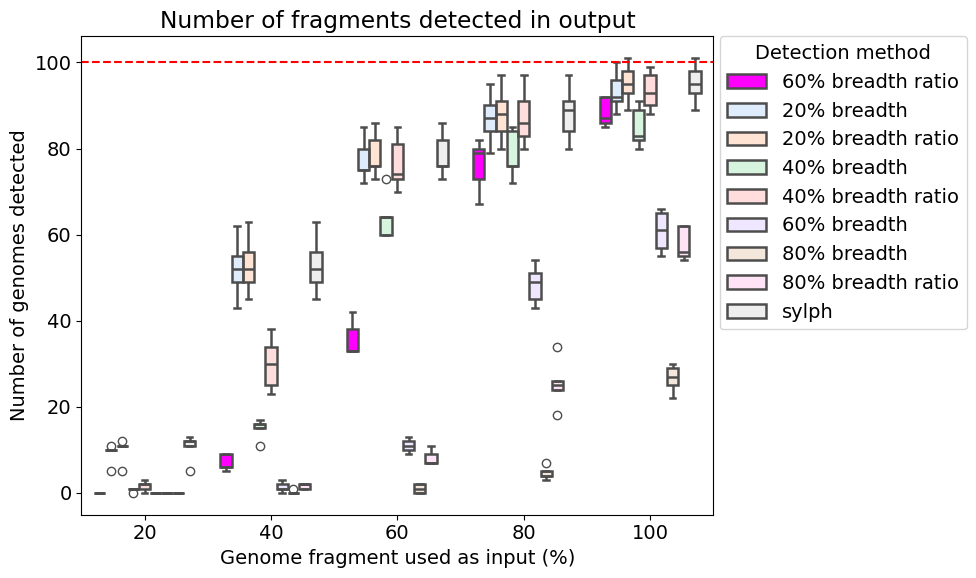

In [7]:
### Compare number of sylph genomes to coverM with different thresholds
plt.rcParams.update({'font.size': 14})
dict_lst = []

for i in range(1, 6):
    for j in [20, 40, 60, 80]:
        # read sylph outputs
        seq_count = (
            pl.read_csv(f'../figure_4/virome_profiling/uhvdb_sylph_profile/fragment_split_{i}/fragment{j}_split_{i}_uhvdb_globdb.profile.tsv', separator='\t', ignore_errors=True)
                .height
        )
        dict_lst.append({
            'replicate': i,
            'fragment_percentage': j,
            'method': f'sylph',
            'num_genomes': seq_count
        })

        # read coverm outputs
        for k in [20, 40, 60, 80, 21, 41, 61, 81]:
            coverm_df = pl.read_csv(
                f'../figure_4/virome_profiling/uhvdb_sylph_profile/fragment_split_{i}/fragment{j}_split_{i}_uhvdb_globdb.coverm.tsv',
                separator='\t',
                ignore_errors=True,
                new_columns=['contig_id', 'trimmed_mean', 'mean', 'covered_bases', 'length']
            )
            if k in [21, 41, 61, 81]:
                covered_genomes = (
                    coverm_df
                        .with_columns([
                            (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
                        ])
                        .with_columns([
                            (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
                        ])
                        .with_columns([
                            (pl.col('breadth') / pl.col('expected_breadth')).alias('breadth_ratio'),
                        ])
                        .filter((pl.col('breadth_ratio') * 100 >= (k - 1)))
                        .height
                )
                dict_lst.append({
                    'replicate': i,
                    'fragment_percentage': j,
                    'method': f'{k-1}% breadth ratio',
                    'num_genomes': covered_genomes
                })
            else:
                covered_genomes = (
                    coverm_df
                        .with_columns([
                            (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
                        ])
                        .with_columns([
                            (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
                        ])
                        .with_columns([
                            (pl.col('breadth') / pl.col('expected_breadth')).alias('breadth_ratio'),
                        ])
                        .filter((pl.col('breadth') * 100 >= k))
                        .height
                )
                dict_lst.append({
                    'replicate': i,
                    'fragment_percentage': j,
                    'method': f'{k}% breadth',
                    'num_genomes': covered_genomes
                })

    # read sylph outputs
    seq_count = (
        pl.read_csv(f'../figure_4/virome_profiling/uhvdb_sylph_profile/split_{i}/split_{i}_uhvdb_globdb.profile.tsv', separator='\t', ignore_errors=True)
            .height
    )
    dict_lst.append({
        'replicate': i,
        'fragment_percentage': 100,
        'method': f'sylph',
        'num_genomes': seq_count
    })

    # read full genome coverm outputs
    for k in [20, 40, 60, 80, 21, 41, 61, 81]:
        coverm_df = pl.read_csv(
            f'../figure_4/virome_profiling/uhvdb_sylph_profile/split_{i}/split_{i}_uhvdb_globdb.coverm.tsv',
            separator='\t',
            ignore_errors=True,
            new_columns=['contig_id', 'trimmed_mean', 'mean', 'covered_bases', 'length']
        )
        if k in [21, 41, 61, 81]:
            covered_genomes = (
                coverm_df
                    .with_columns([
                        (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
                    ])
                    .with_columns([
                        (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
                    ])
                    .with_columns([
                        (pl.col('breadth') / pl.col('expected_breadth')).alias('breadth_ratio'),
                    ])
                    .filter((pl.col('breadth_ratio') * 100 >= (k - 1)))
                    .height
            )
            dict_lst.append({
                'replicate': i,
                'fragment_percentage': 100,
                'method': f'{k-1}% breadth ratio',
                'num_genomes': covered_genomes
            })
        else:
            covered_genomes = (
                coverm_df
                    .with_columns([
                        (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
                    ])
                    .with_columns([
                        (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
                    ])
                    .with_columns([
                        (pl.col('breadth') / pl.col('expected_breadth')).alias('breadth_ratio'),
                    ])
                    .filter((pl.col('breadth') * 100 >= k))
                    .height
            )
            dict_lst.append({
                'replicate': i,
                'fragment_percentage': 100,
                'method': f'{k}% breadth',
                'num_genomes': covered_genomes
            })

# create df from dict_lst
df_sylph = pl.DataFrame(dict_lst)

# highlight 60% breadth ratio brightly, and color all other methods as low-alpha pastel
highlight_method = '60% breadth ratio'
all_methods = sorted(df_sylph['method'].unique().to_list())
hue_order = [highlight_method] + [m for m in all_methods if m != highlight_method] if highlight_method in all_methods else all_methods

non_highlight_methods = [m for m in hue_order if m != highlight_method]
pastel_colors = sns.color_palette('pastel', n_colors=len(non_highlight_methods))
palette = {m: (*c, 0.35) for m, c in zip(non_highlight_methods, pastel_colors)}
if highlight_method in hue_order:
    palette[highlight_method] = '#ff00ff'

# create seaborn boxplot for sylph results
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_sylph,
    x='fragment_percentage',
    y='num_genomes',
    hue='method',
    hue_order=hue_order,
    palette=palette,
    linewidth=1.8,
    saturation=1,
)
plt.title('Number of fragments detected in output')
plt.xlabel('Genome fragment used as input (%)')
plt.ylabel('Number of genomes detected')

# add horizontal line at 100
plt.axhline(y=100, color='r', linestyle='--')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, title='Detection method')
plt.tight_layout()
plt.show()
